<a href="https://colab.research.google.com/github/tasapdien0-commits/Stroke-Prediction-using-Android-app/blob/main/Copy_of_Stroke_Predict.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# A. Khai báo thư viện cần thiết và đưa ra thông tin cơ bản về dữ liệu

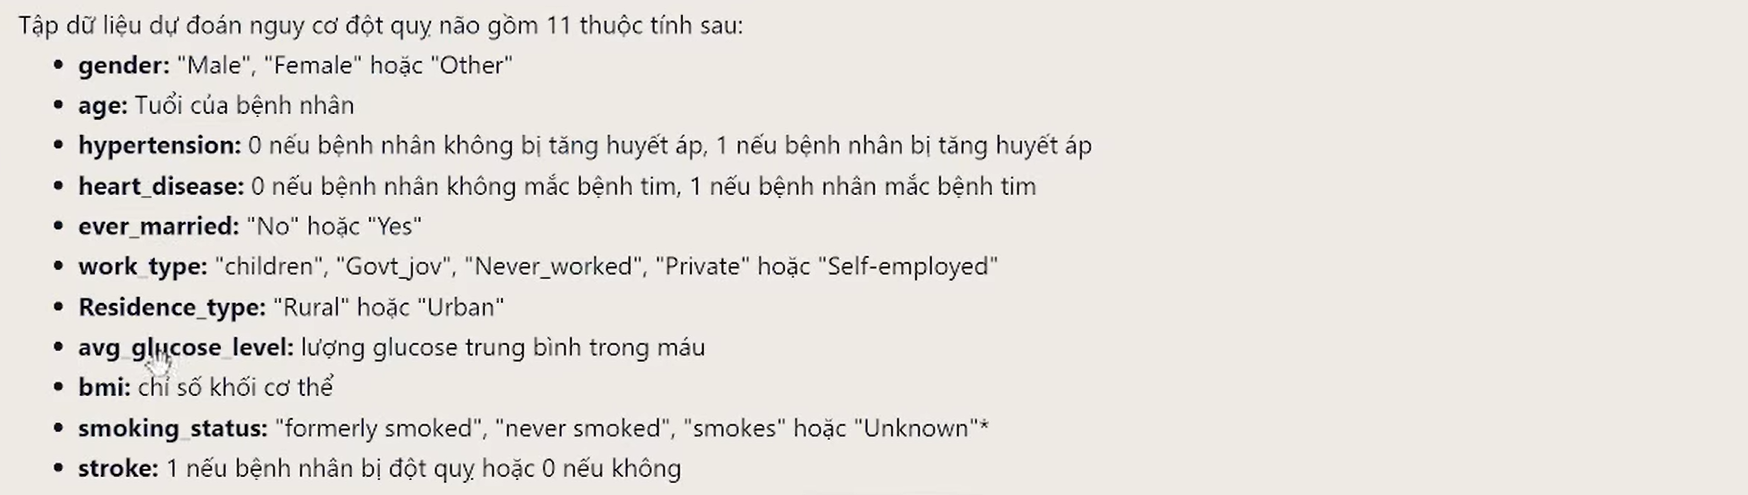

## 1. Khai báo thư viện

In [ ]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import roc_auc_score , classification_report
from sklearn.model_selection import KFold ,StratifiedKFold , train_test_split
from sklearn.preprocessing import LabelEncoder , StandardScaler
from sklearn.metrics import classification_report, f1_score
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.ensemble import GradientBoostingClassifier , RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.compose import ColumnTransformer
from sklearn.metrics import roc_auc_score

## 2. Đọc dữ liệu

In [ ]:
df = pd.read_csv('sample_data/healthcare-dataset-stroke-data.csv')
df.sample(10)

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
145,Male,78.0,1,0,Yes,Self-employed,Rural,56.11,25.5,formerly smoked,1
2756,Male,72.0,0,1,Yes,Private,Urban,99.76,27.1,formerly smoked,0
1021,Female,36.0,0,0,Yes,Govt_job,Rural,82.47,33.1,smokes,0
2387,Male,50.0,0,0,No,Private,Urban,160.94,26.7,smokes,0
4152,Male,37.0,0,0,Yes,Private,Urban,232.29,40.8,smokes,0
2724,Female,23.0,0,0,Yes,Private,Rural,102.88,38.9,Unknown,0
952,Male,55.0,0,0,Yes,Private,Urban,89.17,31.5,never smoked,0
106,Female,80.0,0,0,Yes,Private,Urban,73.54,24.0,Unknown,1
4857,Female,25.0,0,0,No,Private,Urban,92.06,25.3,smokes,0
1942,Female,57.0,0,0,Yes,Private,Rural,84.18,35.5,never smoked,0


## 3. In ra kích thước của dữ liệu

In [ ]:
df.shape

(4909, 11)

## 4. thông tin cơ bản về dữ liệu

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4909 entries, 0 to 4908
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   gender             4909 non-null   object 
 1   age                4909 non-null   float64
 2   hypertension       4909 non-null   int64  
 3   heart_disease      4909 non-null   int64  
 4   ever_married       4909 non-null   object 
 5   work_type          4909 non-null   object 
 6   Residence_type     4909 non-null   object 
 7   avg_glucose_level  4909 non-null   float64
 8   bmi                4909 non-null   float64
 9   smoking_status     4909 non-null   object 
 10  stroke             4909 non-null   int64  
dtypes: float64(3), int64(3), object(5)
memory usage: 422.0+ KB


# B. Tiền xử lý dữ liệu

## 6. In ra dữ liệu cần mã hóa

In [ ]:
print("Những thuộc tính cần mã hóa là: ")
for column in df.columns:
  if np.dtype(df[column]) == 'object':
      print(f"  +) {column}: {df[column].unique()}")


Những thuộc tính cần mã hóa là: 
  +) gender: ['Male' 'Female' 'Other']
  +) ever_married: ['Yes' 'No']
  +) work_type: ['Private' 'Self-employed' 'Govt_job' 'children' 'Never_worked']
  +) Residence_type: ['Urban' 'Rural']
  +) smoking_status: ['formerly smoked' 'never smoked' 'smokes' 'Unknown']


## 7.Mã hóa dùng từ điển ánh xạ

In [ ]:
label_gender = {'Male': 0, 'Female': 1}
label_ever_married = {'Yes': 0, 'No': 1}
label_work_type = {'Private': 0, 'Self-employed': 1, 'Govt_job': 2, 'children': 3}
label_Residence_type = {'Urban': 0, 'Rural': 1}
label_smoking_status = {
    'formerly smoked': 0,
    'never smoked': 1,
    'smokes': 2,
    'Unknown': 3
}

In [ ]:
df['gender'] = df['gender'].map(label_gender)
df['ever_married'] = df['ever_married'].map(label_ever_married)
df['work_type'] = df['work_type'].map(label_work_type)
df['Residence_type'] = df['Residence_type'].map(label_Residence_type)
df['smoking_status'] = df['smoking_status'].map(label_smoking_status)

## 8. In dữ liệu ra sau khi mã hóa

In [ ]:
df.head()

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,0.0,67.0,0,1,0,0.0,0,228.69,36.6,0,1
1,0.0,80.0,0,1,0,0.0,1,105.92,32.5,1,1
2,1.0,49.0,0,0,0,0.0,0,171.23,34.4,2,1
3,1.0,79.0,1,0,0,1.0,1,174.12,24.0,1,1
4,0.0,81.0,0,0,0,0.0,0,186.21,29.0,0,1


## 9.In ra thông tin dữ liệu sau khi mã hóa

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4909 entries, 0 to 4908
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   gender             4908 non-null   float64
 1   age                4909 non-null   float64
 2   hypertension       4909 non-null   int64  
 3   heart_disease      4909 non-null   int64  
 4   ever_married       4909 non-null   int64  
 5   work_type          4887 non-null   float64
 6   Residence_type     4909 non-null   int64  
 7   avg_glucose_level  4909 non-null   float64
 8   bmi                4909 non-null   float64
 9   smoking_status     4909 non-null   int64  
 10  stroke             4909 non-null   int64  
dtypes: float64(5), int64(6)
memory usage: 422.0 KB


In [ ]:
df.corr()['stroke'].sort_values()[:-1]


,stroke
ever_married,-0.105089
smoking_status,-0.075920
work_type,-0.055874
gender,-0.006904
Residence_type,-0.006031
bmi,0.042374
heart_disease,0.137938
avg_glucose_level,0.138936
hypertension,0.142515
age,0.232331


## 10. kiểm tra dữ liệu ngoại lệ cho thuộc tính age dựa trên phân phối

<Axes: ylabel='age'>

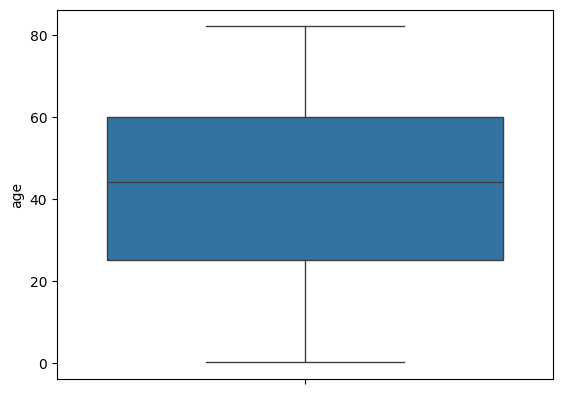

In [ ]:
sns.boxplot(y= 'age', data=df)

## 11. kiểm tra dữ liệu ngoại lệ cho thuộc tính avg_gluco_level dựa trên phân phối



<Axes: ylabel='avg_glucose_level'>

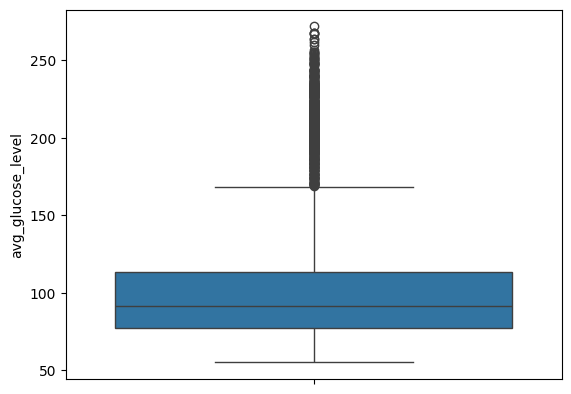

In [ ]:
sns.boxplot(y= 'avg_glucose_level', data=df)

## 12. Tính toán các giá trị Q1, Q2, Q3, IQR, cận trên, cận dưới cho thuộc tính avg_gluco_level

In [ ]:
IQR = df["avg_glucose_level"].quantile(0.75) - df["avg_glucose_level"].quantile(0.25)
lower_limit = df["avg_glucose_level"].quantile(0.25) - (IQR * 1.5)
upper_limit = df["avg_glucose_level"].quantile(0.75) + (IQR * 1.5)

print(f"lower_limit = {lower_limit}")
print(f"upper_limit = {upper_limit}")

lower_limit = 22.319999999999993
upper_limit = 168.32


## 13. thay thế các giá trị cận trên, cận dưới

In [ ]:
df["avg_glucose_level"] = np.where(df["avg_glucose_level"] > upper_limit, upper_limit,
                                   np.where(df["avg_glucose_level"] < lower_limit, lower_limit, df["avg_glucose_level"]))

## 14. kiểm tra phân phối sau khi xử lý ngoại lệ

<Axes: ylabel='avg_glucose_level'>

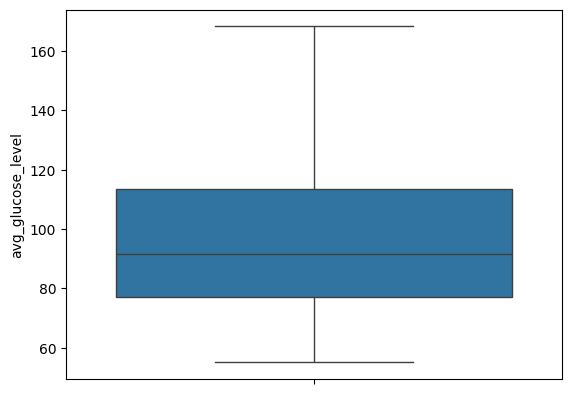

In [ ]:
sns.boxplot(y='avg_glucose_level', data=df)

## 15. kiểm tra dữ liệu ngoại lệ cho thuộc tính BMI dựa trên phân phối


<Axes: ylabel='bmi'>

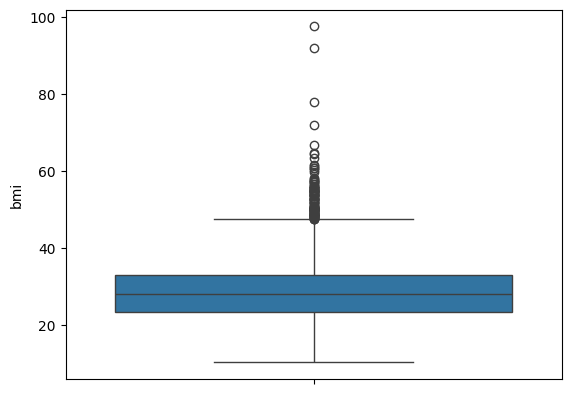

In [ ]:
sns.boxplot(y='bmi', data=df)

## 16. Tính toán các giá trị Q1, Q2, Q3, IQR, cận trên, cận dưới cho thuộc tính bmi

In [ ]:
IQR = df["bmi"].quantile(0.75) - df["bmi"].quantile(0.25)
lower_limit = df["bmi"].quantile(0.25) - (IQR * 1.5)
upper_limit = df["bmi"].quantile(0.75) + (IQR * 1.5)

print(f"lower_limit = {lower_limit}")
print(f"upper_limit = {upper_limit}")

lower_limit = 9.099999999999998
upper_limit = 47.5


## 17. thay thế các giá trị cận trên, cận dưới

In [ ]:
df["bmi"] = np.where(df["bmi"] > upper_limit, upper_limit,
                     np.where(df["bmi"] < lower_limit, lower_limit, df["bmi"]))

## 18. kiểm tra phân phối sau khi xử lý ngoại lệ

<Axes: ylabel='bmi'>

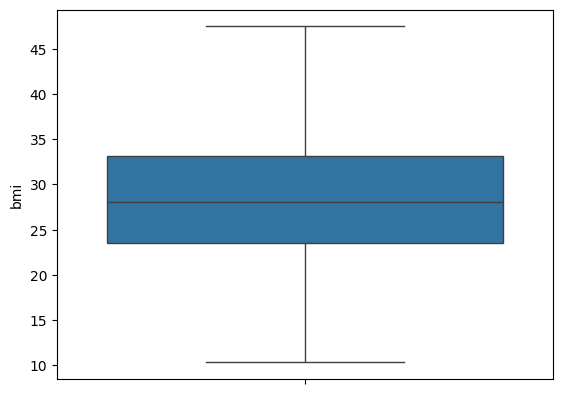

In [ ]:
sns.boxplot(y='bmi', data=df)

## 19. Trọng số của các yếu tố trước khi huấn luyện





In [ ]:
df.corr()['stroke'].sort_values()[:-1]


,stroke
ever_married,-0.105089
smoking_status,-0.075920
work_type,-0.055874
gender,-0.006904
Residence_type,-0.006031
bmi,0.048225
avg_glucose_level,0.119733
heart_disease,0.137938
hypertension,0.142515
age,0.232331


<Axes: >

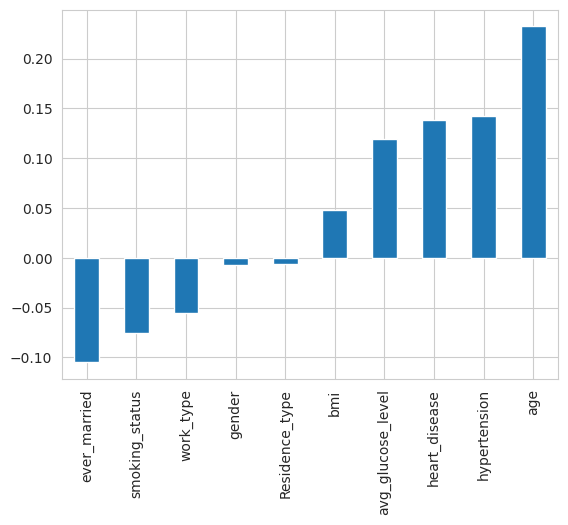

In [ ]:
sns.set_style('whitegrid')
df.corr()['stroke'].sort_values()[:-1].plot.bar()

## 20. Kiểm tra hiện tượng mất cân bằng dữ liệu

/tmp/ipykernel_14894/1709952174.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=label_count.index, y=label_count.values, palette="viridis")


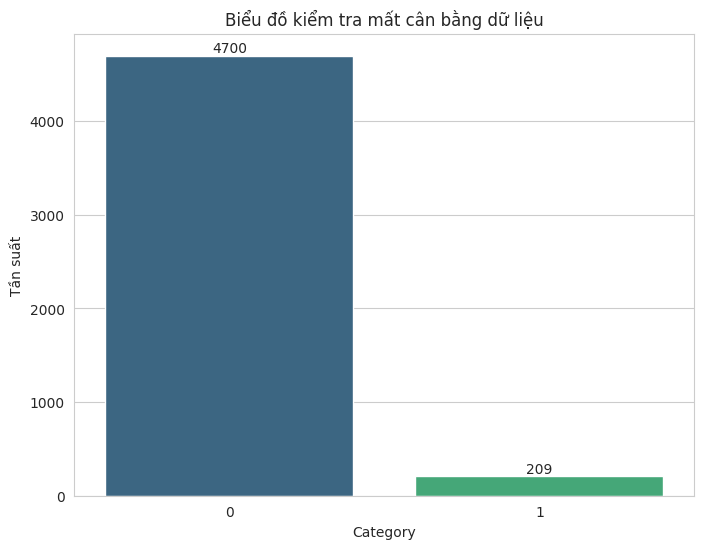

In [ ]:
label_count = df['stroke'].value_counts()
plt.figure(figsize=(8, 6))
sns.barplot(x=label_count.index, y=label_count.values, palette="viridis")
plt.title("Biểu đồ kiểm tra mất cân bằng dữ liệu")
plt.xlabel("Category")
plt.ylabel("Tần suất")
for index, value in enumerate(label_count.values):
    plt.text(index, value + 0.1, str(value), ha='center', va='bottom')

## 20. Sử dụng kỹ thuật Under-sampling xử lý mất cân bằng dữ liệu

In [ ]:
count_stroke = df['stroke'].value_counts()
label_0 = df.loc[df.iloc[:, -1] == 0].sample(count_stroke[1], random_state=32)
label_1 = df.loc[df.iloc[:, -1] == 1]
df = pd.DataFrame(pd.concat([label_0, label_1]))

/tmp/ipykernel_14894/1434330441.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=label_count.index, y=label_count.values, palette="viridis")


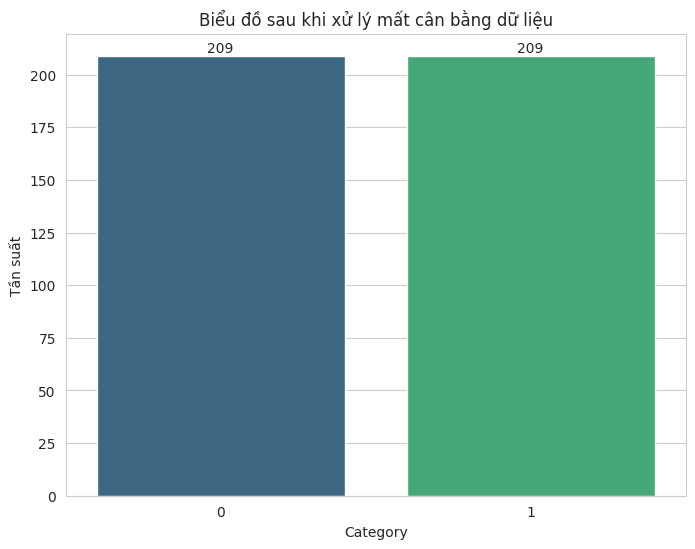

In [ ]:
label_count = df['stroke'].value_counts()

plt.figure(figsize=(8, 6))
sns.barplot(x=label_count.index, y=label_count.values, palette="viridis")
plt.title("Biểu đồ sau khi xử lý mất cân bằng dữ liệu")
plt.xlabel("Category")
plt.ylabel("Tần suất")

for index, value in enumerate(label_count.values):
    plt.text(index, value + 0.1, str(value), ha='center', va='bottom')

## 21. Minh họa dữ liệu chuẩn hóa

<Axes: xlabel='bmi', ylabel='Density'>

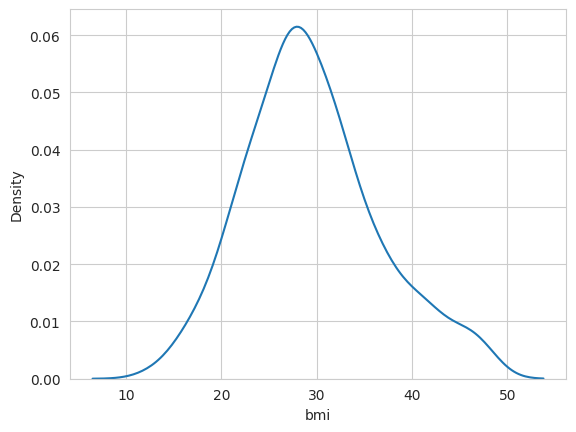

In [ ]:
sns.kdeplot(df['bmi'])

In [ ]:
for column in df.columns:
    max_value = df[column].max()
    min_value = df[column].min()
    df[column] = (df[column] - min_value) / (max_value - min_value)


<Axes: xlabel='bmi', ylabel='Density'>

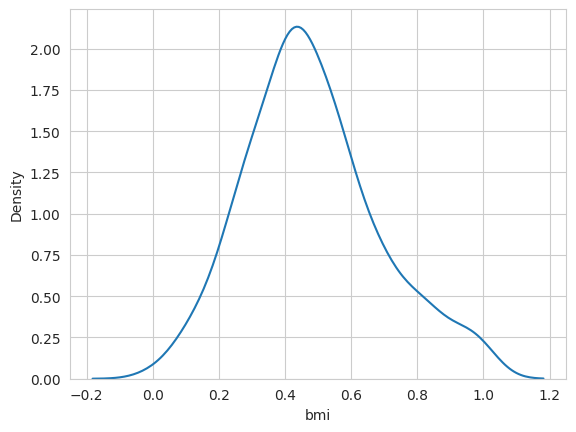

In [ ]:
sns.kdeplot(df['bmi'])

## 23. In ra dữ liệu sau khi chuẩn hóa

In [ ]:
df.head()

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
3947,1.0,0.299410,0.0,0.0,0.0,0.000000,1.0,0.199537,0.455331,0.333333,0.0
3934,1.0,0.422321,0.0,0.0,0.0,0.000000,0.0,0.570716,0.417867,0.333333,0.0
592,0.0,0.582104,0.0,0.0,0.0,0.333333,0.0,0.388201,0.302594,0.000000,0.0
1652,0.0,0.471485,0.0,0.0,0.0,0.000000,0.0,0.322699,0.870317,0.333333,0.0
2707,0.0,0.237955,0.0,0.0,1.0,0.000000,1.0,0.398271,0.953890,0.333333,0.0


In [ ]:
from google.colab import sheets
sheet = sheets.InteractiveSheet(df=df)

https://docs.google.com/spreadsheets/d/1BSZNmuvfcnBQlv5u8qo4R-7Hoge08g8Nnv7Qcusiyv0/edit#gid=0


In [ ]:
df.corr()['stroke'].sort_values()[:-1]


,stroke
ever_married,-0.352114
work_type,-0.171790
smoking_status,-0.170064
Residence_type,-0.009575
gender,0.009663
bmi,0.129963
hypertension,0.236052
heart_disease,0.249907
avg_glucose_level,0.267227
age,0.635662


## 24. In ra kích thước, thông tin về dữ liệu sau khi tiền xử lý





In [ ]:
print(f"Kích thước của dữ liệu là: {df.shape}\n")
print("Thông tin cơ bản về dữ liệu:")
df.info()

Kích thước của dữ liệu là: (418, 11)

Thông tin cơ bản về dữ liệu:
<class 'pandas.core.frame.DataFrame'>
Index: 418 entries, 3947 to 208
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   gender             418 non-null    float64
 1   age                418 non-null    float64
 2   hypertension       418 non-null    float64
 3   heart_disease      418 non-null    float64
 4   ever_married       418 non-null    float64
 5   work_type          418 non-null    float64
 6   Residence_type     418 non-null    float64
 7   avg_glucose_level  418 non-null    float64
 8   bmi                418 non-null    float64
 9   smoking_status     418 non-null    float64
 10  stroke             418 non-null    float64
dtypes: float64(11)
memory usage: 39.2 KB


# C. Chia tập dữ liệu, huấn luyện mô hình và đánh giá mô hình

## 25. Chia dữ liệu thành tập Train, Test theo tỷ lệ 80:20

In [ ]:
X = df.iloc[:, :-1]
y = df.iloc[:, -1]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=True, random_state=28)

## 26. Huấn luyện mô hình sử dụng phương pháp LogisticRegression, Đánh giá, vẽ ma trận nhầm lẫn

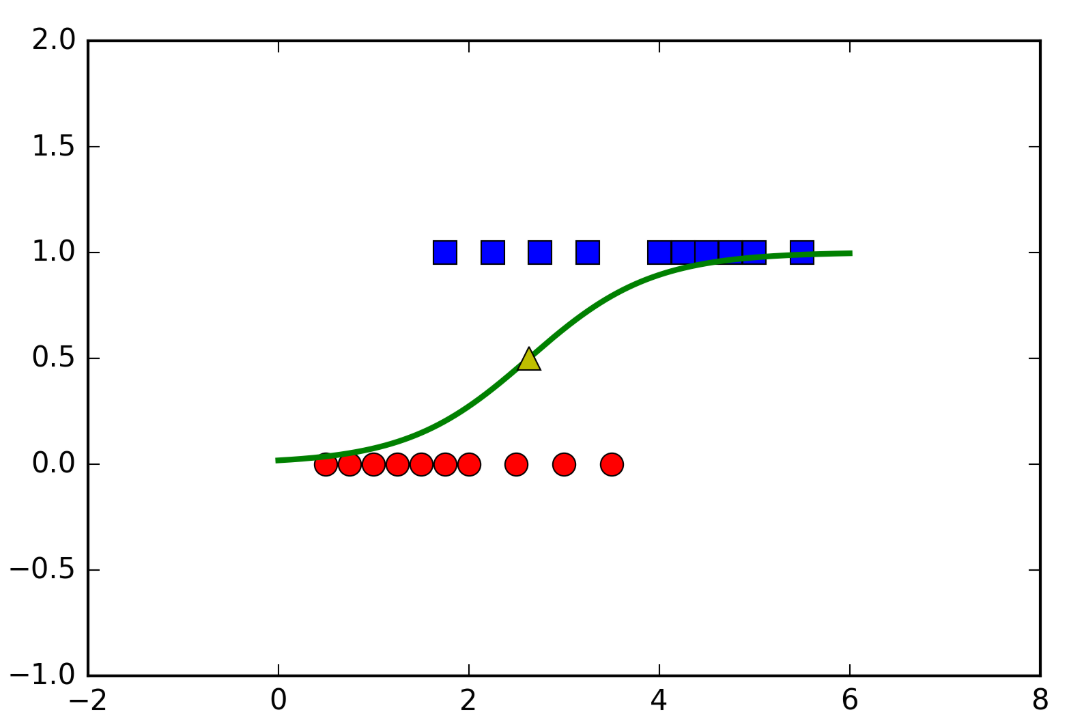

In [ ]:
from sklearn.impute import SimpleImputer

# Impute missing values
imputer_bmi = SimpleImputer(strategy='mean')
imputer_work_type = SimpleImputer(strategy='most_frequent')

# Fit on X_train and transform both X_train and X_test
X_train['bmi'] = imputer_bmi.fit_transform(X_train[['bmi']])
X_test['bmi'] = imputer_bmi.transform(X_test[['bmi']])

X_train['work_type'] = imputer_work_type.fit_transform(X_train[['work_type']])
X_test['work_type'] = imputer_work_type.transform(X_test[['work_type']])

model = LogisticRegression(fit_intercept=False, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted', zero_division=1)
recall = recall_score(y_test, y_pred, average='weighted', zero_division=1)
f1 = f1_score(y_test, y_pred, average='weighted', zero_division=1)

# In các độ đo chất lượng
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Accuracy: 0.7857142857142857
Precision: 0.7857142857142857
Recall: 0.7857142857142857
F1 Score: 0.7857142857142857


<Figure size 800x600 with 0 Axes>

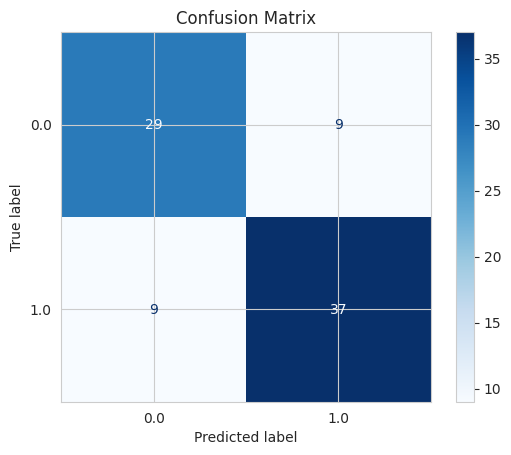

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)

# Vẽ ma trận nhầm lẫn
plt.figure(figsize=(8, 6))
disp.plot(cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

## 27. Trọng số của các yếu tố sau khi đã huấn luyện

In [ ]:
df.corr()['stroke'].sort_values()[:-1]


,stroke
ever_married,-0.352114
work_type,-0.171790
smoking_status,-0.170064
Residence_type,-0.009575
gender,0.009663
bmi,0.129963
hypertension,0.236052
heart_disease,0.249907
avg_glucose_level,0.267227
age,0.635662


<Axes: >

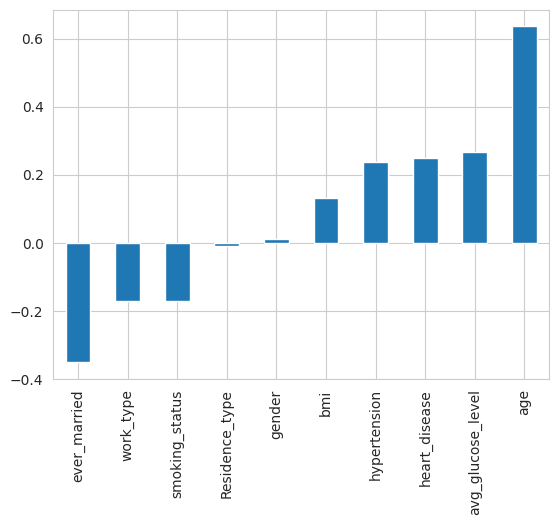

In [ ]:
sns.set_style('whitegrid')
df.corr()['stroke'].sort_values()[:-1].plot.bar()

In [ ]:
print(model.intercept_)

[0.]
